In [12]:
from google.colab import files
uploaded = files.upload()

Saving q1_heart_disease.csv to q1_heart_disease (1).csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

df.head()

Shape: (800, 12)

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Insight: Target Distribution

The distribution of the target variable Heart Disease shows that the dataset is relatively balanced between patients with and without heart disease.

This is beneficial for model training, as it reduces the risk of bias toward one class and ensures that evaluation metrics like precision and recall are reliable.

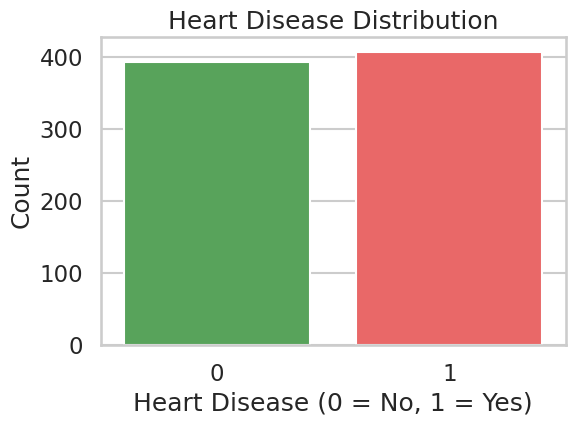

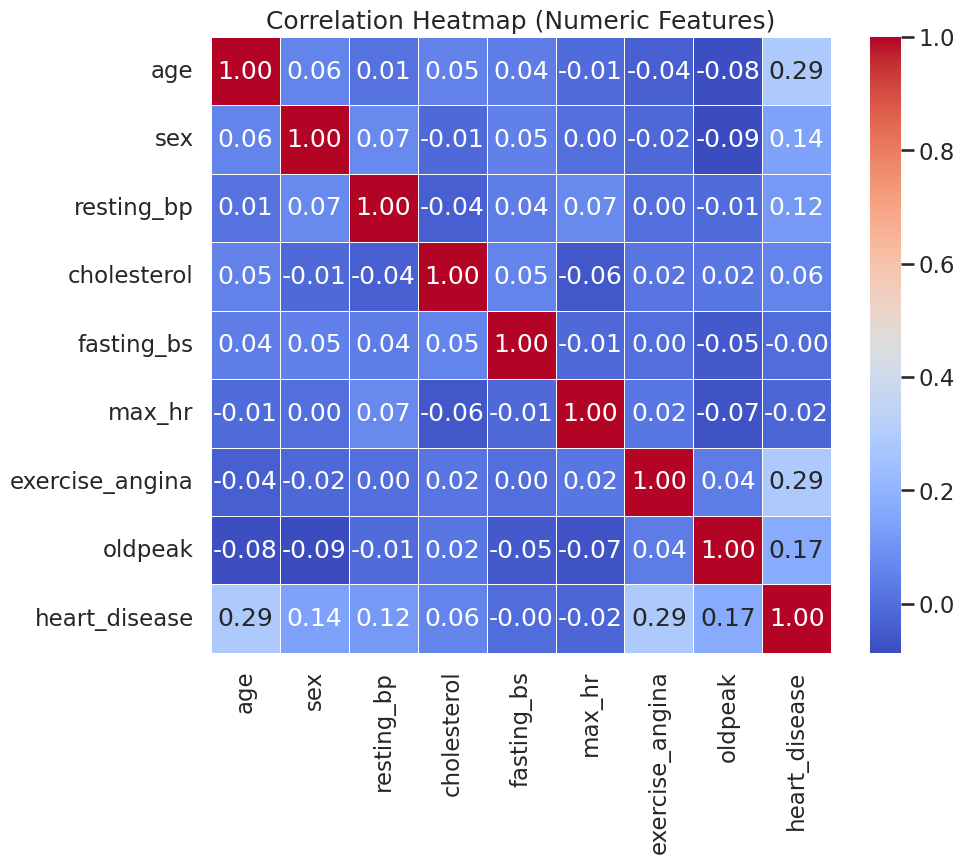

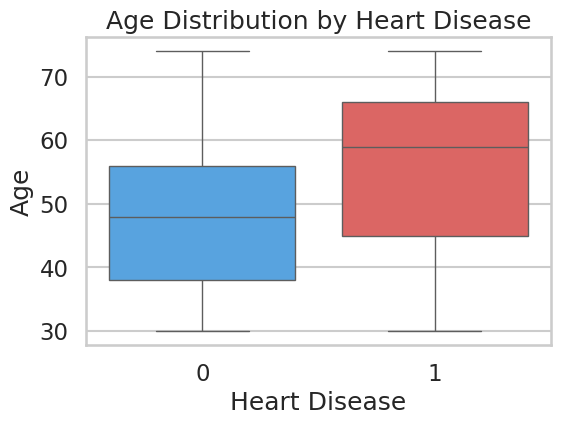

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_style("whitegrid")
sns.set_context("talk")


plt.figure(figsize=(6,4))

sns.countplot(
    x='heart_disease',
    data=df,
    palette=['#4CAF50', '#FF5252']
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()


plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Numeric Features)")

plt.show()



plt.figure(figsize=(6,4))

sns.boxplot(
    x='heart_disease',
    y='age',
    data=df,
    palette=['#42A5F5', '#EF5350']
)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

### Insight: Correlation Analysis

The correlation heatmap shows relationships between numerical features.

- Features like max hr and oldpeak show noticeable correlation with the target variable.
- Some features exhibit weak correlation, indicating they may have limited predictive power individually.
- No extremely high correlation between independent variables suggests low multicollinearity.

Overall, multiple features contribute moderately to predicting heart disease rather than a single dominant factor.   


### Insight: Age vs Heart Disease

The boxplot shows the distribution of age across patients with and without heart disease.

- Patients with heart disease tend to have slightly higher median age.
- There is overlap between the two groups, indicating age alone is not a strong predictor.
- However, age still contributes as an important factor when combined with other features.

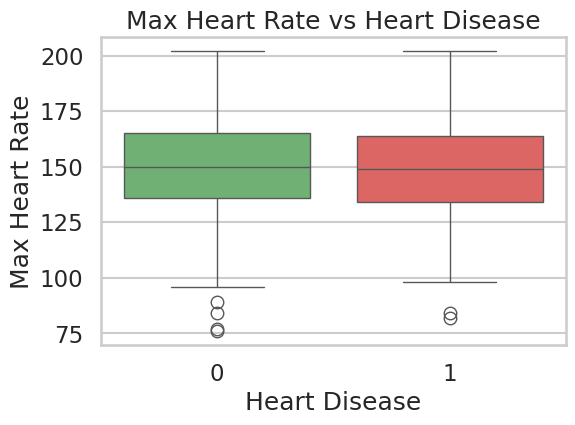

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='heart_disease',
    y='max_hr',
    data=df,
    palette=['#66BB6A', '#EF5350']
)

plt.title("Max Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Max Heart Rate")

plt.show()

### Insight: Max Heart Rate vs Heart Disease

The plot shows that patients without heart disease tend to have higher maximum heart rates compared to those with heart disease.

This suggests that lower maximum heart rate could be associated with higher risk of heart disease, making it an important feature for prediction.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X = X.fillna(X.median(numeric_only=True))

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

###  Model Selection

Gradient Boosting performed the best based on evaluation metrics:

- It achieved the highest **F1-score**, indicating a good balance between precision and recall.
- It maintained strong **recall**, meaning it correctly identified most patients with heart disease.
- It also had fewer false negatives compared to other models, which is critical in healthcare scenarios.

Although Random Forest performed well, Gradient Boosting provided more consistent and slightly better results across all key metrics.

Therefore, **Gradient Boosting is selected as the best-performing model**.

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")
evaluate(gb, "Gradient Boosting")


Decision Tree
[[57 22]
 [25 56]]
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.7

### Model Evaluation and Comparison

Three models were evaluated: Decision Tree, Random Forest, and Gradient Boosting using confusion matrix, precision, recall, and F1-score.

- **Decision Tree** showed moderate performance but is prone to overfitting, leading to less stable results.
- **Random Forest** improved performance by reducing variance through ensemble learning, resulting in better balance between precision and recall.
- **Gradient Boosting** achieved the best overall performance among the three models.  


### Understanding Evaluation Metrics

- **Precision** measures how many predicted positive cases are actually correct.
- **Recall** measures how many actual positive cases were correctly identified.
- **F1-score** is the harmonic mean of precision and recall and provides a balanced evaluation metric.

In medical prediction tasks like heart disease detection, **recall is especially important** because failing to identify a patient with disease (false negative) can have serious consequences.  


### Confusion Matrix Interpretation

The confusion matrix shows:

- True Positives: Correctly predicted heart disease cases
- True Negatives: Correctly predicted non-disease cases
- False Positives: Incorrectly predicted disease cases
- False Negatives: Missed disease cases

The goal is to minimize **false negatives**, as missing a disease case is more critical than a false alarm.

In [19]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_
evaluate(best_model, "Tuned Gradient Boosting")

Best Params: {'max_depth': 3, 'n_estimators': 100}

Tuned Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Overall EDA Summary

From the analysis:
- The dataset is relatively balanced.
- Features such as max heart rate and old peak show meaningful relationships with heart disease.
- No severe multicollinearity is observed.
- Individual features alone are not sufficient, reinforcing the need for machine learning models.

These insights guide the preprocessing and model-building steps.